## CNN based approach(region proposal)
윈도우의 일부(하위 집합) 활용 객체 탐지 효율적

#### Single-Stage Methods
- **정해진 위치와 정해진 크기의 객체**만 찾는 방법. 
- 보통 원본 이미지를 고정된 사이즈 그리드 영역으로 나누고 각 영역에 대해 형태와 크기가 미리 결정된 객체의 고정 개수를 예측
- 2 stage 보다는 정확도가 떨어지지만 빠른 처리가 가능하기 때문에 보통 **실시간** 탐지에 활용
- CNN based object detection 필수가 됨
  - YOLO, SSD, RetinaNet  
  
#### Two-Stage Methods
- 영역 찾은 후 classification
- 객체를 포함할 가능성이 높은 영역을 Selective Search같은 Computer vision 기술을 활용하여 선택해서 제안한 윈도우 세트를 취합하면 회귀 모델과 분류 모델의 수를 공식화해 객체 탐지
  - A. classification
    -  CNN 
  - B. localization 
    - selective search:R-CNN, SPP-net, Fast-RCNN
      - 이전에는 selective search, edge boxes 로 hand-engieered하여 병목현상으로 속도가 느림
      - resize,crop으로 데이터 왜곡

### Selective Search
논문: Selective Search for Object Recognition
- 사람이 지정한 **CTSF( color, texture, size,fill ) 4개 유사도** 기반으로 기준 이상인 경우 region proposals
- **hierachial grouping**: 픽셀 기반으로 주위 유사도 체크하여 기준 이상이면 합침
- 정확도를 위해서 2k개의 가능한 모든경우의 후보 추출
  
    - Capture all scales:모든 객체의 크기를 고려함
    - diversification : 다양한 조건을 고려하여 영역 후보 제안
    - faster computation: exhaustive search에 비해 빠름
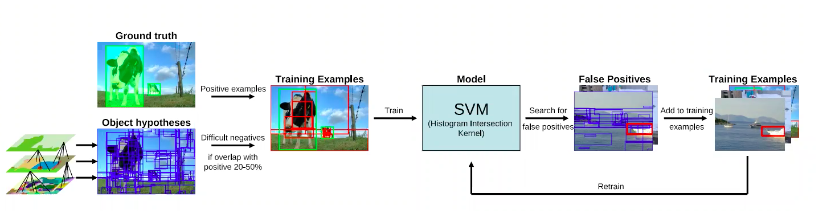

- ground truth 실제 있을 만한 곳(positive)과 20~50% 겹치는 부분(difficult negatives)도 학습 dataset 사용
- SVM model : False Positives 재학습시킴
- 이미지에 들어가고 좌표값이 들어가면 좌표값 4개점 유추

History
- ImageNet classification : AlexNet(2012) 압도적 성능

## R-CNN
논문: Rich features hierarchies for accurate object detection and semantic segmentation

- 최초로 CNN을 Detection에 이용(2013)
- Regions with CNN features
  - Regional proposal + CNN
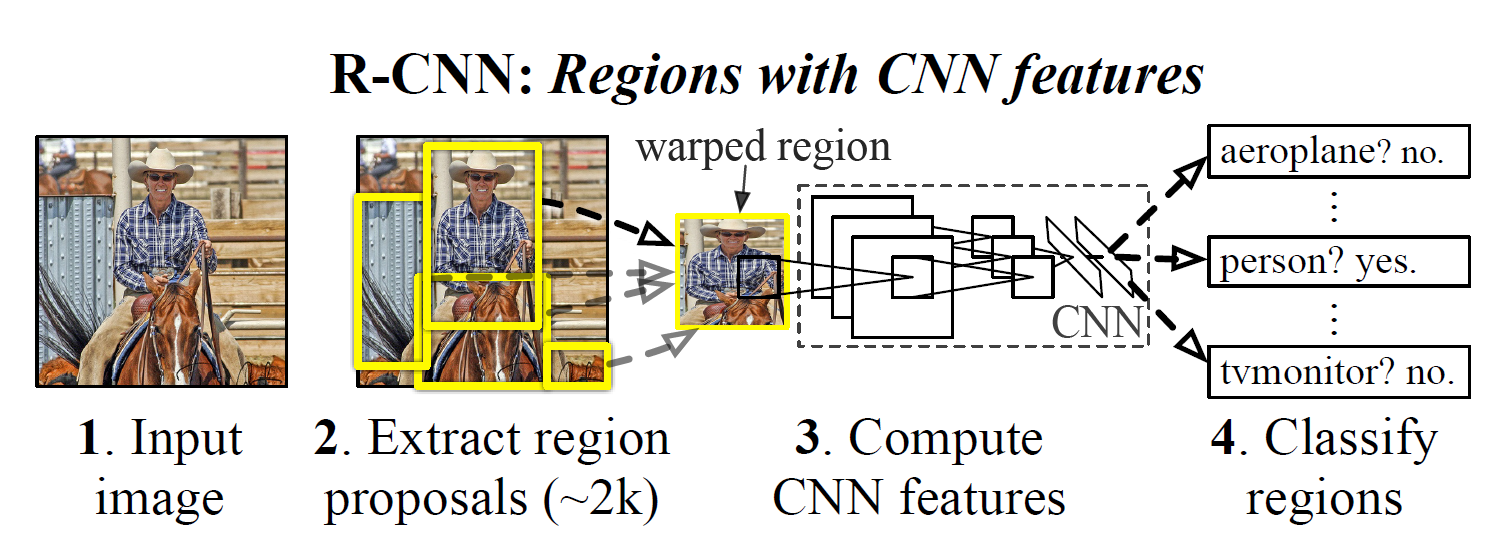

1. limit 2k region proposals 추출(**Selective Search**)
   - 순차적으로 CNN 수행하여 속도가 느림
   - GPU 에 부적합
2. CNN (**AlexNet**)
   - AlexNet 전이학습을 하여 입력이미지가 224*224로 고정되어있어 crop,resize 로인해 이미지 왜곡으로 인한 성능 저하
  - feature extraction
  - localization 성능좋지 못함 
      - positional/transitional invariant 위치에 무관하여 어디에 위치해도 높은 분류 성능을 내나 정확한 위치를 찾아내기에는 부족
   - Vectorizaton 으로 GPU  사용 가능해서 실용적
    1. pre-train CNN for iamge Classificaiton(Transfer Laerning)
      - ImageNEt
    2. Alexnet finetuning for object detection
      - PASCAL VOC (작은 데이터)
      - 데이터 추가 학습

3. SVM
  - 각 region proposal feature에 대한 classification 
  - FCNN, Flatten으로도 충분
  - GPU 에 부적합
4. b-box regressor
    - 검출된 객체의 영역을 알맞은 크기의 사각형 영역으로 표시하고 위치 파악
    -   IOU: Intersection of Union: 전체 이미지 중에서 교집합 되는 정도
    - 좌표 실제값과 selective search 예측값 간의 linear regression model 만들어서 다시 예측해서 localization 정확도 향상
            

문제점
- feature extraction ,classification, regression 3개 모델 학습 어려움
- 정확도를 위해서 2000개 추출해서 순차적 CNN하여 속도 느림
- end-to-end 아니여서 오래걸림
    -   AlexNEt 전이 학습하여 FCNN 입력하기 위해서 강제로 224 크기 맞추기 위해 데이터 resize, crop
- 동시 처리 가능한 GPU 부적합: Region Proposal, SVM
- 모델 학습 3개
  - image feature,
  - classifier
  - regressor
  

### R-CNN 구현
 
1. 데이터셋 불러오기
2. CNN +SVM 모델 합치기
  - transfer learning(include_top=False)
  - 입출력 맞춤

In [1]:
# Jupyter Kernel을 tf210으로 선택한후 아래 코드를 실행한다

In [1]:
import tensorflow as tf
vgg = tf.keras.applications.VGG16(include_top=False)
vgg.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, None, None, 3)]   0         
                                                                 
 block1_conv1 (Conv2D)       (None, None, None, 64)    1792      
                                                                 
 block1_conv2 (Conv2D)       (None, None, None, 64)    36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, None, None, 64)    0         
                                                                 
 block2_conv1 (Conv2D)       (None, None, None, 128)   73856     
                                                                 
 block2_conv2 (Conv2D)       (None, None, None, 128)   147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, None, None, 128)   0     

In [2]:
model = tf.keras.models.Sequential([
    tf.keras.Input((227,227,3)),
#     tf.keras.Input((224,224,3)),
    vgg,
    tf.keras.layers.GlobalAveragePooling2D()
])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, None, None, 512)   14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
Total params: 14,714,688
Trainable params: 14,714,688
Non-trainable params: 0
_________________________________________________________________


In [1]:
# !pip install scikit-image

In [3]:
import skimage.io
image = skimage.io.imread('two_dogs.jpg')
image.shape

(227, 227, 3)

In [4]:
from sklearn.svm import SVC

In [5]:
import numpy as np
model.predict(image[np.newaxis])  # input : (1,227,227,3) ,output :(1,512)

1/1 [==============================] - 0s 401ms/step


array([[1.15495033e+01, 3.01618624e+00, 7.51443291e+00, 0.00000000e+00,
        1.39353180e+01, 7.07041597e+00, 0.00000000e+00, 2.34251335e-01,
        1.34569540e+01, 1.39888018e-01, 1.09803355e+00, 3.37573641e-04,
        1.25884962e+01, 1.13751450e+01, 0.00000000e+00, 1.60134888e+00,
        1.68784034e+00, 2.52305828e-02, 0.00000000e+00, 8.78897607e-01,
        0.00000000e+00, 1.47638810e+00, 0.00000000e+00, 6.45031571e-01,
        0.00000000e+00, 2.56931514e-01, 4.86406118e-01, 2.27345204e+00,
        2.94268870e+00, 0.00000000e+00, 1.90670013e+01, 1.73050385e+01,
        1.78030908e+00, 2.33439064e+00, 1.31935883e+00, 2.53913134e-01,
        2.25103188e+00, 0.00000000e+00, 1.39523067e+01, 3.84516335e+01,
        2.53967514e+01, 0.00000000e+00, 3.63630486e+00, 3.88455701e+00,
        1.00568466e+01, 7.91145921e-01, 2.25596023e+00, 3.81025076e+00,
        2.00686884e+00, 3.21190357e+00, 5.02893031e-01, 2.85162354e+00,
        8.70860040e-01, 4.06861663e-01, 2.29571795e+00, 7.422243

In [6]:
svm = SVC()
print(type(svm))

<class 'sklearn.svm._classes.SVC'>


-selective search 결과로 나온 이미지 - b-box 좌표값, 데이터셋 생성해서 모델을 따로 2개 만들어야함 

-모델 구현은 문제가 안 됨  
SVM 안쓰고 구현

-RCNN 성능  
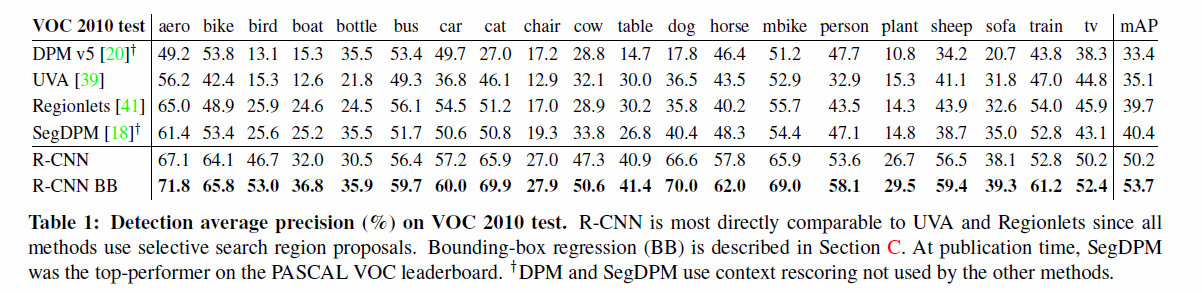

- CNN, R-CNN은 Fully connected layer 때문에 입력의 크기가 고정되야함  

## SPP-net 
- Kaiming He SPPNet(2014) ,ResNet(2015)
- Spatial pyramid pooling in DCNN for visual recognotion

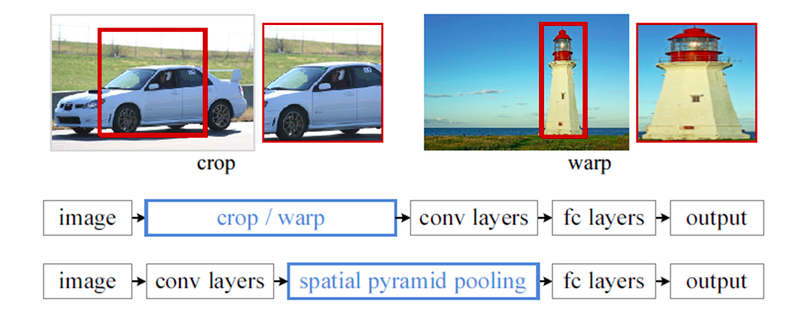
- **cropping,warping 문제점** 해결하기 위해서 **입력 이미지 크기 맞추지 않아도 CNN 적용** 할 수 있도록 **Spatial pyramid pooling(SPP)*으로 영상 크기 대응
- 마지막 convolution 레이어의 feature map에서 activation강도와 spatial information 포함하므로 convolution 다음에 pooling
    > ZFnet :컨볼루션 시각화: 가장 강한 activation 된 부분은 밝은색(큰값)-> 특징 존재

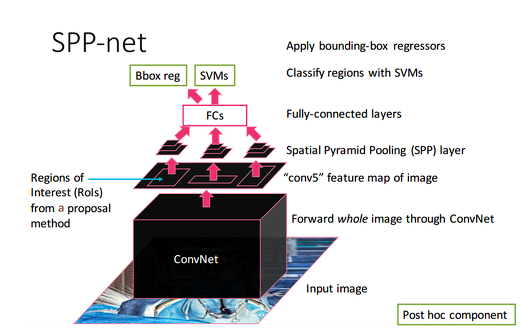

#### BoW(bag-of-Words)  
https://wikidocs.net/22650  
 - 자연어처리에서 글에서 포함된 단어들의 분포를 보고 문서를 자동 분류  

#### Bag of Visual Words  

https://towardsdatascience.com/bag-of-visual-words-in-a-nutshell-9ceea97ce0fb  


- 영상처리에서는 이미지 특징에 따라서 분류,검색, 인식에 사용

1. feature extraction
2. k means clustering
    - 추출된 feature 군집화, 대표적 특징( cluster center) 찾음
3. codebook generation
    - 물체 인식에 중요한 주요 feature를 대표할 수 있는 코드로 구성되는 코드북 
4. image representation
    - codebook 이용 이미지의 특징을 추출한 후 추출된 각각의 특징들에 대해 코드북 내에서 대응하는 코드워드 찾음
    - 코드워드들의 히스토그램으로 이미지 특징 표현
    - 각각의 코드워드가 이미지에서 나타난 갯수
5. Learning and recognition
    - disciminative : feature vector로 해석하여 SVM classifier
    - generative : 확률로 해석해여 Beyesian 
    
    - 이미지를 여러개의 일정 개수의 지역으로 나눈 뒤, 각 지역에 BoW를 적용하여 지역적인 정보를 어느정도 유지
    - 크기 조각별로 매칭하는 기법
    
    

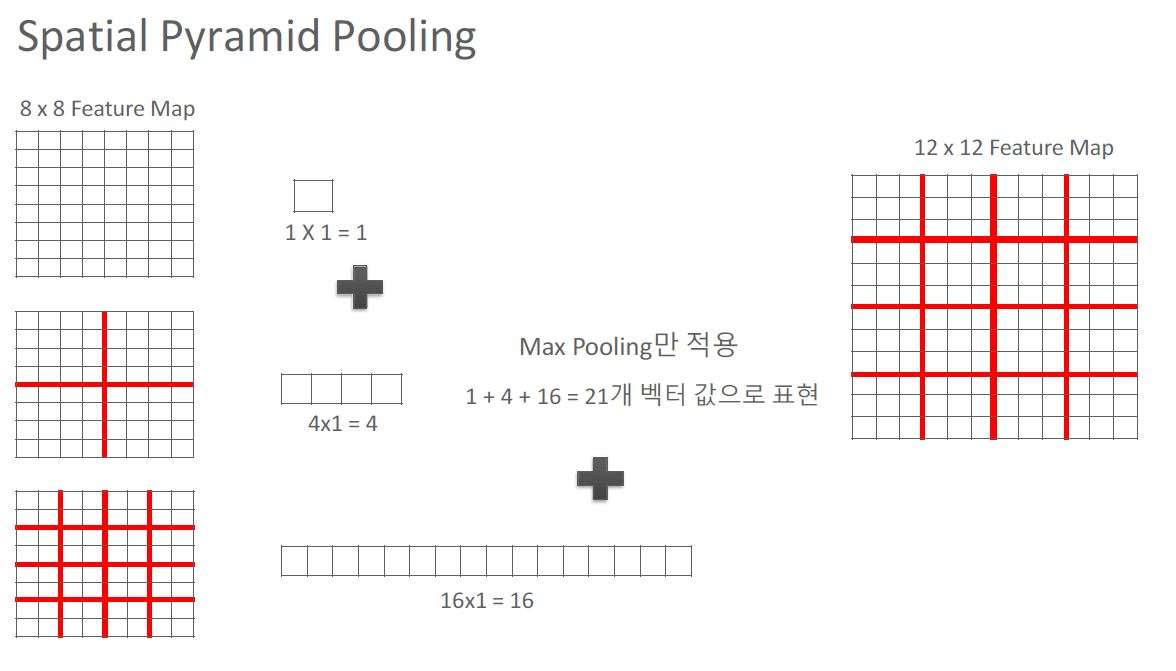

- 이미지를 여러 단계의 resolution으로 분할 후, 각 단계의 분할영역마다 히스토그램을 구하여 이들을 전체적으로 비교하면 pyramid 형성되며 비교하여 두 이미지의 유사도 측정함
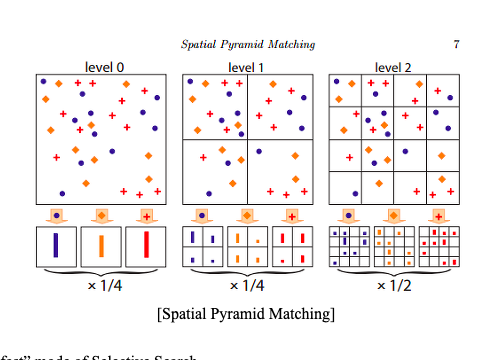

#### Spatial pyramid pooling
- convolution의 feature map을 정해진 숫자로 분할하고 각각 pooling(영역은 작아지면서 특징 유지)으로 피라미드처럼 쌓아서 BoW 확장하여 이미지 크기 상관없이 입력 받음 
    1. 영상 전체를 커버할 수 있도록 1x1 pooling
    2. 영상을 4개의 영역으로 구분한 2x2 pooling
    3. 영상을 9개의 영역으로 구분은 3x3 pooling 

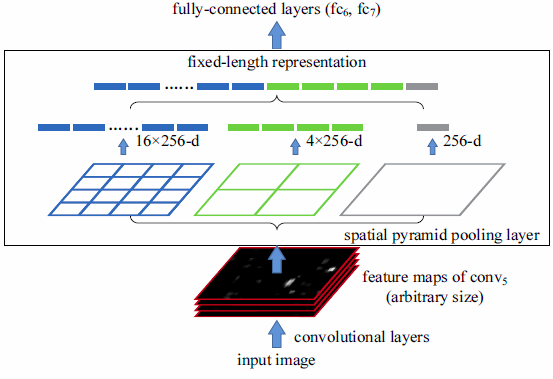

- 위치별로 어떤 특징이 많은지 위치 추가된 특징을 알 수 있어서 detection에서 proposal 이 더 좋아짐

In [7]:
# SPPNet: spatial pyramid pooling layer
dir(tf.keras.layers) #기본으로 제공해주는 layer 에서는 없음  -> 이미 만들어진 거 기반으로  "상속" 

['AbstractRNNCell',
 'Activation',
 'ActivityRegularization',
 'Add',
 'AdditiveAttention',
 'AlphaDropout',
 'Attention',
 'Average',
 'AveragePooling1D',
 'AveragePooling2D',
 'AveragePooling3D',
 'AvgPool1D',
 'AvgPool2D',
 'AvgPool3D',
 'BatchNormalization',
 'Bidirectional',
 'CategoryEncoding',
 'CenterCrop',
 'Concatenate',
 'Conv1D',
 'Conv1DTranspose',
 'Conv2D',
 'Conv2DTranspose',
 'Conv3D',
 'Conv3DTranspose',
 'ConvLSTM1D',
 'ConvLSTM2D',
 'ConvLSTM3D',
 'Convolution1D',
 'Convolution1DTranspose',
 'Convolution2D',
 'Convolution2DTranspose',
 'Convolution3D',
 'Convolution3DTranspose',
 'Cropping1D',
 'Cropping2D',
 'Cropping3D',
 'Dense',
 'DenseFeatures',
 'DepthwiseConv1D',
 'DepthwiseConv2D',
 'Discretization',
 'Dot',
 'Dropout',
 'ELU',
 'EinsumDense',
 'Embedding',
 'Flatten',
 'GRU',
 'GRUCell',
 'GaussianDropout',
 'GaussianNoise',
 'GlobalAveragePooling1D',
 'GlobalAveragePooling2D',
 'GlobalAveragePooling3D',
 'GlobalAvgPool1D',
 'GlobalAvgPool2D',
 'GlobalAvgPo

##  SPP 레이어 구현

### 사용자 정의 layer
- 참고: https://www.tensorflow.org/tutorials/customization/custom_layers?hl=ko
- 기본으로 제공하지 않는경우 `tf.keras.layers.Layer` 상속해서 학습에 필요하면 사용자 정의 layer 만들어야함
  - 학습 불필요하면 Lamba layer 로 해결
  

- __init__ 클래스 인스턴스 실행시 초기화
    -  *arg, **kwargs 인자  상관없이 받아서 초기화시 편리
- build summary 전에 갯수 자동적으로 맞춰줌
- call
  - 인스턴스 () 한 경우 내부적으로__call__ 부름 

In [8]:
tf.keras.layers.Layer #기본 레이어 상속 받음

keras.engine.base_layer.Layer

In [9]:
class SPPLayer(tf.keras.layers.Layer):
    def __init__(self,num_outputs):
        super(SPPLayer, self).__init__()
        self.num_outputs=num_outputs    

In [10]:
spp = SPPLayer(3)

In [11]:
spp(3)

<tf.Tensor: shape=(), dtype=int32, numpy=3>

tf.keras.layers.Layer `__build__`,`__call__` 있어서 `build`, `call` 오버로딩

In [12]:
class SPPLayer(tf.keras.layers.Layer):
  #초기화 ,   
  def __init__(self, *arg, **kwargs):
    super().__init__(*arg, **kwargs)

  def __build__(self,x):
    print('build')

  def __call__(self, x):
    print('call')

In [13]:
#가장 기본적 구조 

class SPPLayer(tf.keras.layers.Layer):
 
  def __init__(self, *arg, **kwargs):
    super().__init__(*arg, **kwargs)
  # 오버로딩
  def build(self,x):
    print('build')
  def call(self, x):
    print('call')

In [14]:
spp = SPPLayer()

- 인스턴스() -> build(한번만 실행됨, 실행 되어있으면 skip -> call
- build는 1번만 불리기 때문에 optional
- 레이어 값 전달 함수형 패러다임
    - 입력값 받아서 행렬곱해서 다음 레이어 전달해서 output 전달해줄값 만듦

In [15]:
spp(3)

build
call


In [16]:
spp(4)  # 이미 한번 실행되서 build 안 부름 

call


- image 전체 pooling
  - max pooling
   1. tf.keras.layers.Max
   2. tf.keras.backend
    - keras 에서  쓸 수 있는 함수, class 제공
    - 동일하게 지원하는 기능 외로 각 프레임워크별로 지원되는 기능 
    - 각 차이점을 맞춰서 실행하게 해주도록 함 tf, tiano,CNTK
    - 차이가 날만한 메소드 : 기본적 연산은 차이가 남 , 케라스에서 사용 가능한 함수, 메소드 제공
- filter갯수 만큼 convolution
> R-CNN : resize,warping 

In [17]:
from tensorflow.keras import backend as K
#지금은 tf전용이지만 이전에는 tf, tiano, CNTK - 각 프레임 워크별 지원하는 기능 (내부적으로 차이점을 맞춰줘서 실행시키게 해줌) 함수,클래스 제공 

### backend
Keras는 딥러닝 모델을 개발하기 위한 고수준의 구성요성 요소를 제공하는 모델 레벨의 라이브러리입니다.
Keras는 텐서 곱셈, 합성곱 등의 저수준의 연산을 제공하지 않습니다
대신 Keras의 "백엔드 엔진" 역할을 하는 특수하고 잘 최적화 된 텐서 라이브러리에 의존합니다
https://keras.io/ko/backend/


내부적으로 tf 자제적으로 없는 메소드가 있는데 같은 메소드라도 keras, tf 상이함
- 케라스: 넘파이 기반
- 텐서플로우: 텐서 기반

In [18]:
dir(K)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_sys',
 'abs',
 'all',
 'any',
 'arange',
 'argmax',
 'argmin',
 'backend',
 'batch_dot',
 'batch_flatten',
 'batch_get_value',
 'batch_normalization',
 'batch_set_value',
 'bias_add',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'cast',
 'cast_to_floatx',
 'categorical_crossentropy',
 'clear_session',
 'clip',
 'concatenate',
 'constant',
 'conv1d',
 'conv2d',
 'conv2d_transpose',
 'conv3d',
 'cos',
 'count_params',
 'ctc_batch_cost',
 'ctc_decode',
 'ctc_label_dense_to_sparse',
 'cumprod',
 'cumsum',
 'depthwise_conv2d',
 'dot',
 'dropout',
 'dtype',
 'elu',
 'epsilon',
 'equal',
 'eval',
 'exp',
 'expand_dims',
 'experimental',
 'eye',
 'flatten',
 'floatx',
 'foldl',
 'foldr',
 'function',
 'gather',
 'get_uid',
 'get_value',
 'gradients',
 'greater',
 'greater_equal',
 'hard_sigmoid',
 'image_data_format',
 'in_test_phase',
 'in_top_k',
 'in_tr

In [19]:
#동일한 메소드라도 케라스에서 제공하는것과 tf 제공하는것이 다름
K.maximum is tf.maximum

False

In [20]:
np.maximum([1,20,3],[4,5,6])

array([ 4, 20,  6])

In [21]:
K.max

<function keras.backend.max(x, axis=None, keepdims=False)>

In [22]:
class SPPLayer(tf.keras.layers.Layer):

  def __init__(self, filters, *arg, **kwargs):
    self.filters=filters
    super().__init__(*arg, **kwargs)
    
  # 값 집어 넣을때 output 값 전달
  def call(self, x):
    outputs=[]
    
    for f in self.filters(): #filter 갯수만큼 해야함  , 이미지 shape
        K.max()   #return -> output 맞추면서 concatnate  (numpy: stack,concat)
        win_size=K.int_shape
    return K.concatnate(outputs)

### shape
- 분할하기 위해서 필요
    - 1 개 : shape 
    - 2 개 : shape/2  
- 각각의 영역에서 max pooling 가능   
flatten 1차원  특별한 부분을 convolution 하면

In [23]:
### shape
np.array([[1,2,3]]).shape

(1, 3)

In [24]:
# 크기(shape)을 int로 리턴
h,w = K.int_shape(np.array([[1,2,3]]))
print(h,w)
h/2,w/2

1 3


(0.5, 1.5)

### stride
- 각 dimensions를 건너가는데 몇 bytes나 뛰어넘어야 하는지에 대한 정보
- 3x3 Flatten
- 넘파이 데이터 저장 관리- > max 빨리 구할 수 있음 

In [25]:
### stride
a=np.arange(1,10) #1열로 관리 
a

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

In [26]:
a.strides # stride로 n차원 만듦  -> 빠르게 관리 가능

(4,)

In [27]:
a = a.reshape(3,3)
a.strides     # (dimensions 간의 간격, element간의 간격)

(12, 4)

In [28]:
a

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [29]:
class SPPLayer(tf.keras.layers.Layer):

    def __init__(self, pool_list, **kwargs):

        self.pool_list = pool_list

        self.num_outputs_per_channel = sum([i * i for i in pool_list])

        super(SpatialPyramidPooling, self).__init__(**kwargs)
        
        # https://www.tensorflow.org/addons/api_docs/python/tfa/layers/SpatialPyramidPooling2D

    def build(self, input_shape):
            self.nb_channels = input_shape[3]

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.nb_channels * self.num_outputs_per_channel)

    def get_config(self):
        config = {'pool_list': self.pool_list}
        base_config = super(SpatialPyramidPooling, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))

    def call(self, x, mask=None):

        input_shape = K.shape(x)


        for pool_num, num_pool_regions in enumerate(self.pool_list):
            for jy in range(num_pool_regions):
                for ix in range(num_pool_regions):
                    
                    # x축과 y축의 시작점과 끝점 계산
                    # col_length와 row_length는 입력 데이터의 크기에 대한 정보를 담고 있는 리스트
                    x1 = ix * col_length[pool_num]
                    x2 = ix * col_length[pool_num] + col_length[pool_num]
                    y1 = jy * row_length[pool_num]
                    y2 = jy * row_length[pool_num] + row_length[pool_num]

                    x1 = K.cast(K.round(x1), 'int32')
                    x2 = K.cast(K.round(x2), 'int32')
                    y1 = K.cast(K.round(y1), 'int32')
                    y2 = K.cast(K.round(y2), 'int32')

                    new_shape = [input_shape[0], y2 - y1,
                                 x2 - x1, input_shape[3]]
                    
                    # 풀링 영역을 이용하여 입력 데이터를잘라낸다
                    x_crop = x[:, y1:y2, x1:x2, :]
                    xm = K.reshape(x_crop, new_shape)
                    
                    pooled_val = K.max(xm, axis=(1, 2))  # 1번,2번축에 대한 최대값 추출
                    outputs.append(pooled_val)

        outputs = K.concatenate(outputs)  # 결과를 하나로 합침
       
        return outputs